In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_churn_dataset.csv'
)

df.head()

,CustomerID,LastPurchase,FirstPurchase,TotalOrders,Revenue,CustomerAge,DaysSinceLastPurchase,Churn,Segment
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,325,325,1,At Risk
1,12347.0,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,366,1,0,Champions
2,12348.0,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,357,74,0,At Risk
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,18,18,0,Potential Loyalist
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,309,309,1,At Risk


In [14]:
df['CLV'] = df['Revenue']

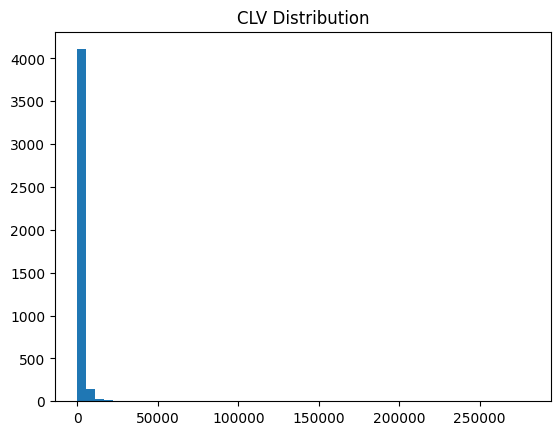

In [15]:
plt.hist(df['CLV'], bins=50)
plt.title('CLV Distribution')
plt.show()

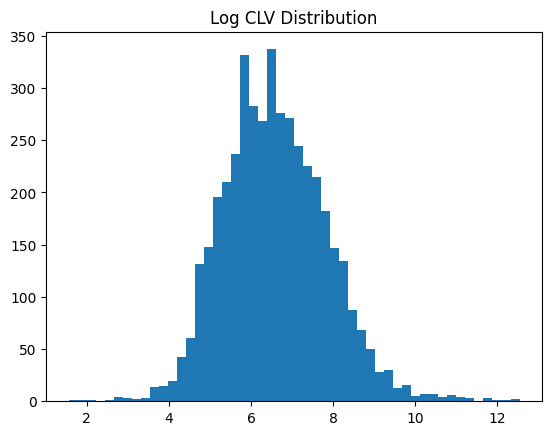

In [16]:
df['CLV_Log'] = np.log1p(df['CLV'])
plt.hist(df['CLV_Log'], bins=50)
plt.title('Log CLV Distribution')
plt.show()

In [17]:
rfm = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/rfm_customer_segments.csv'
)

In [18]:
df = df.merge(
    rfm[['CustomerID','Recency','Frequency']],
    on='CustomerID',
    how='left'
)

In [19]:
features = [
    'TotalOrders',
    'CustomerAge',
    'Recency',
    'Frequency'
]

In [20]:
X = df[features]
y = df['CLV_Log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
pred_lr = lr.predict(X_test)

In [23]:
print(
    "R2:",
    r2_score(y_test, pred_lr)
)

print(
    "MAE:",
    mean_absolute_error(y_test, pred_lr)
)

R2: 0.5843234139269897
MAE: 0.6315839056802897


In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
pred_rf = rf.predict(X_test)
print(
    "R2:",
    r2_score(y_test, pred_rf)
)

print(
    "MAE:",
    mean_absolute_error(y_test, pred_rf)
)

R2: 0.6207895767556793
MAE: 0.5950408089747972


In [27]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest'
    ],
    'R2':[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ],
    'MAE':[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ]
})

results

,Model,R2,MAE
0,Linear Regression,0.584323,0.631584
1,Random Forest,0.620790,0.595041


In [28]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

In [29]:
importance = (
    importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

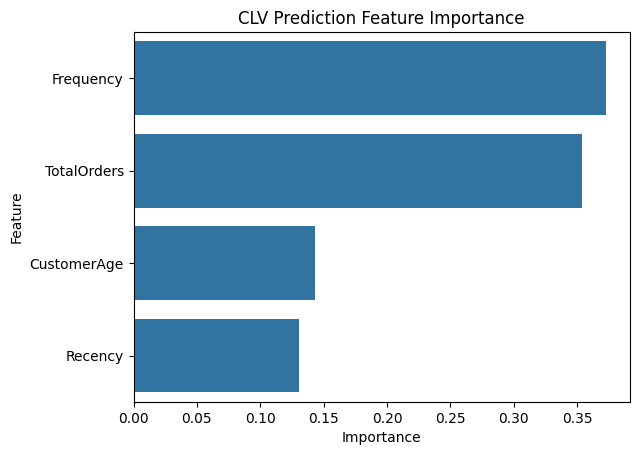

In [30]:
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'CLV Prediction Feature Importance'
)

plt.show()

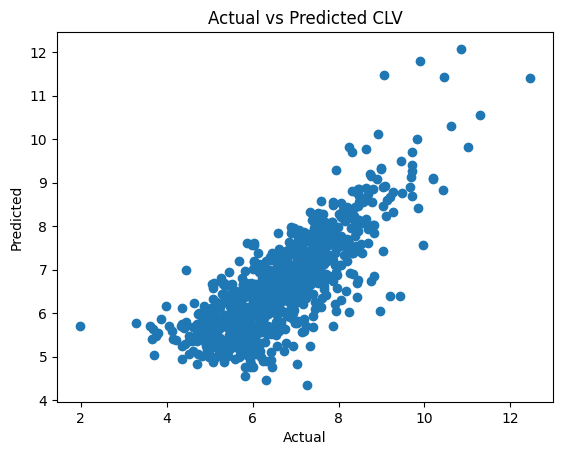

In [31]:
plt.scatter(
    y_test,
    pred_rf
)

plt.xlabel('Actual')

plt.ylabel('Predicted')

plt.title(
    'Actual vs Predicted CLV'
)

plt.show()

In [32]:
df['Predicted_CLV'] = rf.predict(X)

In [33]:
df['Predicted_CLV'] = np.expm1(df['Predicted_CLV'])

In [34]:
df['CLV_Segment'] = pd.qcut(
    df['Predicted_CLV'],
    3,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value'
    ]
)

In [35]:
df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_clv_predictions.csv',
    index=False
)

In [36]:
importance.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/clv_feature_importance.csv',
    index=False
)